In [37]:
import os
import random
import math
import time
import json
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torchvision.datasets import OxfordIIITPet
from PIL import Image
from scipy import ndimage

Часть A. Классификация изображений (STL10)

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


Загрузка STL10

In [3]:
# Параметры
BATCH_SIZE = 64
IMG_SIZE = 96          # оригинальный размер STL10
IMG_SIZE_RESNET = 224  # для ResNet

# Нормализация для STL10
STL10_MEAN = (0.4467, 0.4398, 0.4066)
STL10_STD  = (0.2603, 0.2566, 0.2713)

# Нормализация для ImageNet (ResNet)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Трансформы для CNN без аугментаций
transform_base = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD)
])

# Трансформы с аугментациями
transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD)
])

# Трансформы для ResNet (ImageNet)
transform_resnet_base = transforms.Compose([
    transforms.Resize((IMG_SIZE_RESNET, IMG_SIZE_RESNET)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

transform_resnet_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE_RESNET, IMG_SIZE_RESNET)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [4]:
def load_stl10(data_dir='./data'):
    ds_train_full = datasets.STL10(root=data_dir, split='train', download=True, transform=None)
    ds_test = datasets.STL10(root=data_dir, split='test', download=True, transform=None)
    return ds_train_full, ds_test

ds_train_full, ds_test = load_stl10()

In [7]:
val_ratio = 0.2
n_train = int(len(ds_train_full) * (1 - val_ratio))
n_val = len(ds_train_full) - n_train
ds_train, ds_val = random_split(ds_train_full, [n_train, n_val], generator=torch.Generator().manual_seed(42))
print(f"Train: {len(ds_train)}, Val: {len(ds_val)}, Test: {len(ds_test)}")

Train: 4000, Val: 1000, Test: 8000


Создание DataLoaderов

In [5]:
class TransformDataset(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, idx):
        x, y = self.dataset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

In [8]:
def make_loaders(ds_train, ds_val, ds_test, transform_train, transform_val):
    ds_train = TransformDataset(ds_train, transform_train)
    ds_val   = TransformDataset(ds_val, transform_val)
    ds_test  = TransformDataset(ds_test, transform_val)
    train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
    val_loader   = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
    test_loader  = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
    return train_loader, val_loader, test_loader

    ds_train = Wrapper(ds_train, transform_train)
    ds_val = Wrapper(ds_val, transform_val)
    ds_test = Wrapper(ds_test, transform_val)

    train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader

train_loader_base, val_loader_base, test_loader_base = make_loaders(ds_train, ds_val, ds_test, transform_base, transform_base)
train_loader_aug, val_loader_aug, test_loader_aug = make_loaders(ds_train, ds_val, ds_test, transform_aug, transform_base)
train_loader_resnet_base, val_loader_resnet_base, _ = make_loaders(ds_train, ds_val, ds_test, transform_resnet_base, transform_resnet_base)
train_loader_resnet_aug, val_loader_resnet_aug, _ = make_loaders(ds_train, ds_val, ds_test, transform_resnet_aug, transform_resnet_base)

Визуализация аугментаций

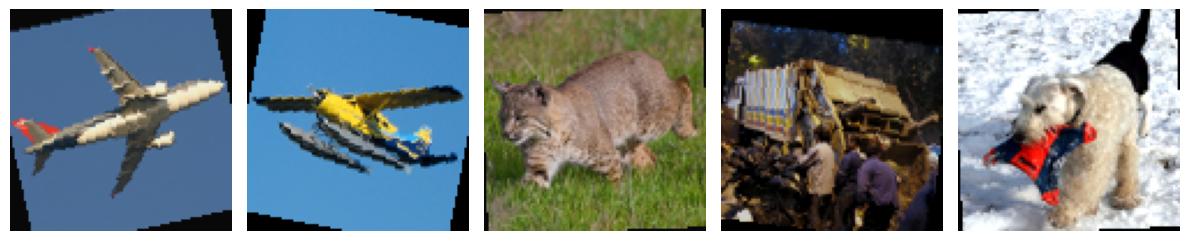

In [9]:
def show_augmentations(dataset, n=5):
    plt.figure(figsize=(12, 3))
    for i in range(n):
        idx = i % len(dataset)
        x, _ = dataset[idx]
        # денормализация
        mean = torch.tensor(STL10_MEAN).view(3,1,1)
        std = torch.tensor(STL10_STD).view(3,1,1)
        x = x * std + mean
        img = x.permute(1,2,0).clip(0,1).numpy()
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.tight_layout()
    plt.savefig('artifacts/figures/augmentations_preview.png')
    plt.show()

# Визуализируем несколько примеров из датасета с аугментациями
sample_dataset = TransformDataset(ds_train, transform_aug)   # используем тот же датасет, что и в train_loader_aug
show_augmentations(sample_dataset, n=5)

Функции обучения и оценки

In [10]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_seen += bs
    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_seen += bs
    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs, verbose=True):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        if verbose:
            print(f"Epoch {epoch:2d}/{epochs} | train loss {tr_loss:.4f}, acc {tr_acc:.3f} | val loss {val_loss:.4f}, acc {val_acc:.3f}")
    return history

Модели

In [11]:
# Простая CNN
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 96 -> 48
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 48 -> 24
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 24 -> 12
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Функция для ResNet с заменой головы
def get_resnet18(pretrained=True, num_classes=10):
    if pretrained:
        try:
            from torchvision.models import ResNet18_Weights
            weights = ResNet18_Weights.DEFAULT
            model = models.resnet18(weights=weights)
        except (NameError, ImportError, AttributeError):
            model = models.resnet18(pretrained=True)
    else:
        model = models.resnet18()
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module, flag):
    for p in module.parameters():
        p.requires_grad = flag

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Эксперименты

In [12]:
criterion = nn.CrossEntropyLoss()
EPOCHS = 15
results = []

In [13]:
# C1: SimpleCNN без аугментаций
model_c1 = SimpleCNN().to(DEVICE)
optimizer = optim.Adam(model_c1.parameters(), lr=1e-3)
hist_c1 = fit(model_c1, train_loader_base, val_loader_base, optimizer, criterion, EPOCHS)
best_val_acc = max(hist_c1['val_acc'])
results.append({
    'experiment_id': 'C1',
    'task': 'classification',
    'dataset': 'STL10',
    'seed': 42,
    'model_summary': 'SimpleCNN',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'epochs_trained': EPOCHS,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'no augmentations'
})

Epoch  1/15 | train loss 1.8758, acc 0.300 | val loss 1.5968, acc 0.387
Epoch  2/15 | train loss 1.4638, acc 0.460 | val loss 1.3931, acc 0.484
Epoch  3/15 | train loss 1.1980, acc 0.569 | val loss 1.3970, acc 0.492
Epoch  4/15 | train loss 0.9367, acc 0.655 | val loss 1.2788, acc 0.547
Epoch  5/15 | train loss 0.6760, acc 0.763 | val loss 1.3557, acc 0.564
Epoch  6/15 | train loss 0.4253, acc 0.851 | val loss 1.5338, acc 0.563
Epoch  7/15 | train loss 0.2396, acc 0.920 | val loss 1.7414, acc 0.570
Epoch  8/15 | train loss 0.1403, acc 0.958 | val loss 2.0221, acc 0.589
Epoch  9/15 | train loss 0.0590, acc 0.985 | val loss 2.4435, acc 0.561
Epoch 10/15 | train loss 0.0348, acc 0.992 | val loss 2.6374, acc 0.565
Epoch 11/15 | train loss 0.0324, acc 0.991 | val loss 2.5484, acc 0.559
Epoch 12/15 | train loss 0.0416, acc 0.987 | val loss 2.6586, acc 0.572
Epoch 13/15 | train loss 0.0862, acc 0.974 | val loss 2.6543, acc 0.575
Epoch 14/15 | train loss 0.0474, acc 0.988 | val loss 2.6772, ac

In [14]:
# C2: SimpleCNN с аугментациями
model_c2 = SimpleCNN().to(DEVICE)
optimizer = optim.Adam(model_c2.parameters(), lr=1e-3)
hist_c2 = fit(model_c2, train_loader_aug, val_loader_aug, optimizer, criterion, EPOCHS)
best_val_acc = max(hist_c2['val_acc'])
results.append({
    'experiment_id': 'C2',
    'task': 'classification',
    'dataset': 'STL10',
    'seed': 42,
    'model_summary': 'SimpleCNN',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'epochs_trained': EPOCHS,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'with augmentations'
})

Epoch  1/15 | train loss 1.9418, acc 0.279 | val loss 1.5467, acc 0.414
Epoch  2/15 | train loss 1.5275, acc 0.450 | val loss 1.4700, acc 0.446
Epoch  3/15 | train loss 1.4037, acc 0.487 | val loss 1.3739, acc 0.496
Epoch  4/15 | train loss 1.2726, acc 0.536 | val loss 1.3009, acc 0.529
Epoch  5/15 | train loss 1.1552, acc 0.578 | val loss 1.2328, acc 0.541
Epoch  6/15 | train loss 1.1118, acc 0.600 | val loss 1.2573, acc 0.555
Epoch  7/15 | train loss 0.9989, acc 0.642 | val loss 1.1715, acc 0.594
Epoch  8/15 | train loss 0.9348, acc 0.669 | val loss 1.2125, acc 0.577
Epoch  9/15 | train loss 0.8664, acc 0.691 | val loss 1.1591, acc 0.601
Epoch 10/15 | train loss 0.8478, acc 0.693 | val loss 1.0796, acc 0.612
Epoch 11/15 | train loss 0.7421, acc 0.740 | val loss 1.0910, acc 0.621
Epoch 12/15 | train loss 0.7105, acc 0.747 | val loss 1.1106, acc 0.621
Epoch 13/15 | train loss 0.6487, acc 0.765 | val loss 1.1871, acc 0.613
Epoch 14/15 | train loss 0.5953, acc 0.787 | val loss 1.2023, ac

In [15]:
model_c3 = get_resnet18(pretrained=True, num_classes=10).to(DEVICE)
set_requires_grad(model_c3, False)
set_requires_grad(model_c3.fc, True)
optimizer = optim.Adam(model_c3.fc.parameters(), lr=1e-3)
hist_c3 = fit(model_c3, train_loader_resnet_base, val_loader_resnet_base, optimizer, criterion, EPOCHS)
best_val_acc = max(hist_c3['val_acc'])
results.append({
    'experiment_id': 'C3',
    'task': 'classification',
    'dataset': 'STL10',
    'seed': 42,
    'model_summary': 'ResNet18 (pretrained)',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'epochs_trained': EPOCHS,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'head-only, no augmentations'
})

Epoch  1/15 | train loss 1.1113, acc 0.711 | val loss 0.4591, acc 0.931
Epoch  2/15 | train loss 0.3689, acc 0.921 | val loss 0.3006, acc 0.933
Epoch  3/15 | train loss 0.2662, acc 0.941 | val loss 0.2485, acc 0.943
Epoch  4/15 | train loss 0.2148, acc 0.949 | val loss 0.2266, acc 0.939
Epoch  5/15 | train loss 0.1889, acc 0.950 | val loss 0.2040, acc 0.946
Epoch  6/15 | train loss 0.1624, acc 0.960 | val loss 0.1967, acc 0.939
Epoch  7/15 | train loss 0.1516, acc 0.961 | val loss 0.1840, acc 0.946
Epoch  8/15 | train loss 0.1362, acc 0.967 | val loss 0.1842, acc 0.945
Epoch  9/15 | train loss 0.1333, acc 0.965 | val loss 0.1879, acc 0.940
Epoch 10/15 | train loss 0.1209, acc 0.964 | val loss 0.1815, acc 0.949
Epoch 11/15 | train loss 0.1196, acc 0.966 | val loss 0.1809, acc 0.943
Epoch 12/15 | train loss 0.1101, acc 0.971 | val loss 0.1762, acc 0.947
Epoch 13/15 | train loss 0.1097, acc 0.969 | val loss 0.1807, acc 0.946
Epoch 14/15 | train loss 0.1013, acc 0.974 | val loss 0.1737, ac

In [16]:
# C4: ResNet18 fine-tune (layer4+fc)
model_c4 = get_resnet18(pretrained=True, num_classes=10).to(DEVICE)
set_requires_grad(model_c4, False)
set_requires_grad(model_c4.layer4, True)
set_requires_grad(model_c4.fc, True)
params = [
    {'params': model_c4.layer4.parameters(), 'lr': 1e-4},
    {'params': model_c4.fc.parameters(), 'lr': 1e-3}
]
optimizer = optim.Adam(params)
hist_c4 = fit(model_c4, train_loader_resnet_aug, val_loader_resnet_aug, optimizer, criterion, EPOCHS)
best_val_acc = max(hist_c4['val_acc'])
results.append({
    'experiment_id': 'C4',
    'task': 'classification',
    'dataset': 'STL10',
    'seed': 42,
    'model_summary': 'ResNet18 (pretrained)',
    'optimizer': 'Adam',
    'lr': 'layer4:1e-4, fc:1e-3',
    'epochs_trained': EPOCHS,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'partial fine-tune with augmentations'
})

Epoch  1/15 | train loss 0.5786, acc 0.829 | val loss 0.2010, acc 0.940
Epoch  2/15 | train loss 0.1659, acc 0.951 | val loss 0.2043, acc 0.941
Epoch  3/15 | train loss 0.0957, acc 0.973 | val loss 0.1818, acc 0.942
Epoch  4/15 | train loss 0.0634, acc 0.981 | val loss 0.1835, acc 0.946
Epoch  5/15 | train loss 0.0414, acc 0.989 | val loss 0.1818, acc 0.944
Epoch  6/15 | train loss 0.0357, acc 0.990 | val loss 0.1906, acc 0.944
Epoch  7/15 | train loss 0.0221, acc 0.995 | val loss 0.1987, acc 0.946
Epoch  8/15 | train loss 0.0228, acc 0.993 | val loss 0.2080, acc 0.950
Epoch  9/15 | train loss 0.0144, acc 0.997 | val loss 0.1887, acc 0.945
Epoch 10/15 | train loss 0.0105, acc 0.998 | val loss 0.1830, acc 0.954
Epoch 11/15 | train loss 0.0133, acc 0.997 | val loss 0.2167, acc 0.952
Epoch 12/15 | train loss 0.0104, acc 0.998 | val loss 0.2279, acc 0.943
Epoch 13/15 | train loss 0.0126, acc 0.996 | val loss 0.2198, acc 0.946
Epoch 14/15 | train loss 0.0079, acc 0.997 | val loss 0.2298, ac

In [17]:
best_idx = max(range(len(results)), key=lambda i: results[i]['best_val_accuracy'])
best_model = [model_c1, model_c2, model_c3, model_c4][best_idx]
best_config = results[best_idx].copy()

# Финальная оценка на тесте
test_acc = evaluate(best_model, test_loader_base, criterion)[1]
best_config['test_accuracy'] = test_acc
results[best_idx]['test_accuracy'] = test_acc

print(f"\nЛучшая модель: {best_config['experiment_id']} с val accuracy {best_config['best_val_accuracy']:.4f}, test accuracy {test_acc:.4f}")


Лучшая модель: C4 с val accuracy 0.9540, test accuracy 0.7572


In [18]:
# Сохранение модели
torch.save(best_model.state_dict(), 'artifacts/best_classifier.pt')

# Сохранение конфига
config = {
    'dataset': best_config['dataset'],
    'model': best_config['model_summary'],
    'transforms': 'transform_resnet_aug' if best_config['experiment_id'] in ['C3','C4'] else 'transform_base',
    'epochs': best_config['epochs_trained'],
    'lr': best_config['lr'],
    'seed': 42
}
with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=2)

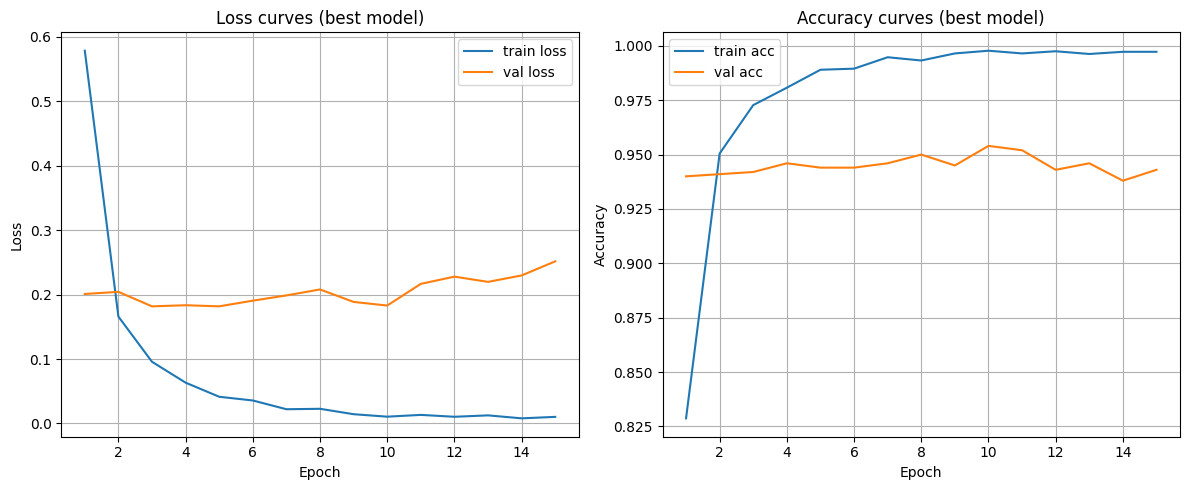

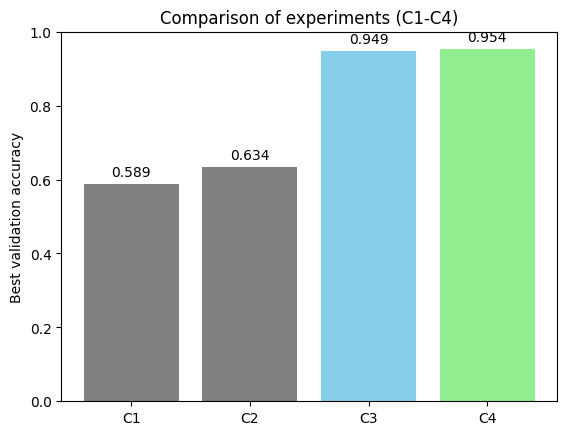

In [19]:
# График обучения лучшей модели
best_hist = [hist_c1, hist_c2, hist_c3, hist_c4][best_idx]
epochs = range(1, EPOCHS+1)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, best_hist['train_loss'], label='train loss')
plt.plot(epochs, best_hist['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.title('Loss curves (best model)')

plt.subplot(1,2,2)
plt.plot(epochs, best_hist['train_acc'], label='train acc')
plt.plot(epochs, best_hist['val_acc'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.title('Accuracy curves (best model)')
plt.tight_layout()
plt.savefig('artifacts/figures/classification_curves_best.png')
plt.show()

# Сравнение best_val_accuracy
exp_ids = [r['experiment_id'] for r in results]
val_accs = [r['best_val_accuracy'] for r in results]
plt.bar(exp_ids, val_accs, color=['gray','gray','skyblue','lightgreen'])
plt.ylabel('Best validation accuracy')
plt.title('Comparison of experiments (C1-C4)')
plt.ylim(0, 1)
for i, v in enumerate(val_accs):
    plt.text(i, v+0.02, f'{v:.3f}', ha='center')
plt.savefig('artifacts/figures/classification_compare.png')
plt.show()

Часть B. Сегментация на OxfordIIITPet

In [38]:
def pet_mask_transform(mask):
    # Значения маски: 0 – фон, 1 – питомец, 2 – граница, 3 – игнорировать
    mask = mask.resize((256, 256), Image.NEAREST)
    mask = np.array(mask)
    binary_mask = (mask == 1).astype(np.int64)   # только питомец
    return torch.tensor(binary_mask, dtype=torch.long)

In [39]:
class PetDatasetWithBinaryMask(Dataset):
    def __init__(self, dataset, transform, target_transform):
        self.dataset = dataset
        self.transform = transform
        self.target_transform = target_transform
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, idx):
        img, mask = self.dataset[idx]
        img = self.transform(img)
        mask = self.target_transform(mask)
        return img, mask

In [40]:
ds_pet = OxfordIIITPet(root='./data', split='trainval', target_types='segmentation', download=True)
n_total = len(ds_pet)
n_train = int(0.8 * n_total)
n_val = n_total - n_train
ds_train_pet, ds_val_pet = random_split(ds_pet, [n_train, n_val], generator=torch.Generator().manual_seed(42))

In [41]:
mean = (0.485, 0.456, 0.406)
std  = (0.229, 0.224, 0.225)
pet_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_dataset_pet = PetDatasetWithBinaryMask(ds_train_pet, pet_transform, pet_mask_transform)
val_dataset_pet   = PetDatasetWithBinaryMask(ds_val_pet, pet_transform, pet_mask_transform)

train_loader_pet = DataLoader(train_dataset_pet, batch_size=8, shuffle=True, num_workers=0)
val_loader_pet   = DataLoader(val_dataset_pet, batch_size=8, shuffle=False, num_workers=0)

In [42]:
CLASS_CAT = 8
CLASS_DOG = 12

In [43]:
# Загрузка предобученной модели DeepLabV3
model_seg = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)
model_seg = model_seg.to(DEVICE)
model_seg.eval()
print("Модель сегментации загружена")

Модель сегментации загружена


In [44]:
def compute_metrics(pred_mask, true_mask):
    tp = ((pred_mask == 1) & (true_mask == 1)).sum().item()
    fp = ((pred_mask == 1) & (true_mask == 0)).sum().item()
    fn = ((pred_mask == 0) & (true_mask == 1)).sum().item()
    tn = ((pred_mask == 0) & (true_mask == 0)).sum().item()
    iou = tp / (tp + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    return iou, precision, recall

def denorm_image(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(DEVICE)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(DEVICE)
    img = img_tensor * std + mean
    img = img.clamp(0, 1)
    return img.permute(1,2,0).cpu().numpy()

In [45]:
@torch.no_grad()
def evaluate_segmentation_pet(model, loader, threshold=0.5, postprocess=None):
    model.eval()
    total_iou = 0.0
    total_precision = 0.0
    total_recall = 0.0
    n_samples = 0
    for images, masks in loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        output = model(images)['out']          # (B, 21, H, W)
        probs = torch.softmax(output, dim=1)
        # Суммируем вероятности для cat и dog
        prob_pet = probs[:, CLASS_CAT, :, :] + probs[:, CLASS_DOG, :, :]
        pred = (prob_pet > threshold).long()
        if postprocess:
            pred = postprocess(pred)
        for i in range(images.size(0)):
            iou, prec, rec = compute_metrics(pred[i], masks[i])
            total_iou += iou
            total_precision += prec
            total_recall += rec
            n_samples += 1
    return total_iou / n_samples, total_precision / n_samples, total_recall / n_samples

In [46]:
def postprocess_remove_small_components(mask_tensor, min_size=50):
    mask_np = mask_tensor.cpu().numpy().astype(np.uint8)
    out = []
    for m in mask_np:
        labeled, num = ndimage.label(m)
        sizes = ndimage.sum(m, labeled, range(num+1))
        for i in range(1, num+1):
            if sizes[i] < min_size:
                m[labeled == i] = 0
        out.append(torch.tensor(m, dtype=torch.long))
    return torch.stack(out).to(mask_tensor.device)

In [47]:
metrics_v1 = evaluate_segmentation_pet(model_seg, val_loader_pet, threshold=0.3, postprocess=None)
print(f"V1 (thresh=0.3): IoU={metrics_v1[0]:.4f}, Precision={metrics_v1[1]:.4f}, Recall={metrics_v1[2]:.4f}")

V1 (thresh=0.3): IoU=0.7012, Precision=0.7161, Recall=0.9631


In [48]:
def postprocess_min_size(mask):
    return postprocess_remove_small_components(mask, min_size=200)

In [49]:
metrics_v2 = evaluate_segmentation_pet(model_seg, val_loader_pet, threshold=0.7, postprocess=postprocess_min_size)
print(f"V2 (thresh=0.7 + postprocess): IoU={metrics_v2[0]:.4f}, Precision={metrics_v2[1]:.4f}, Recall={metrics_v2[2]:.4f}")

V2 (thresh=0.7 + postprocess): IoU=0.7592, Precision=0.7916, Recall=0.9308


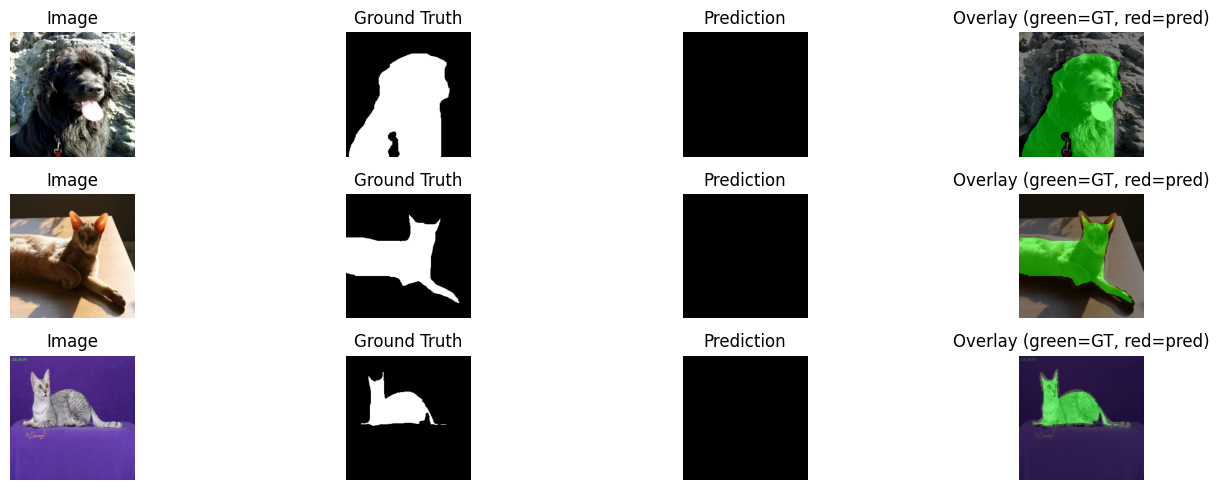

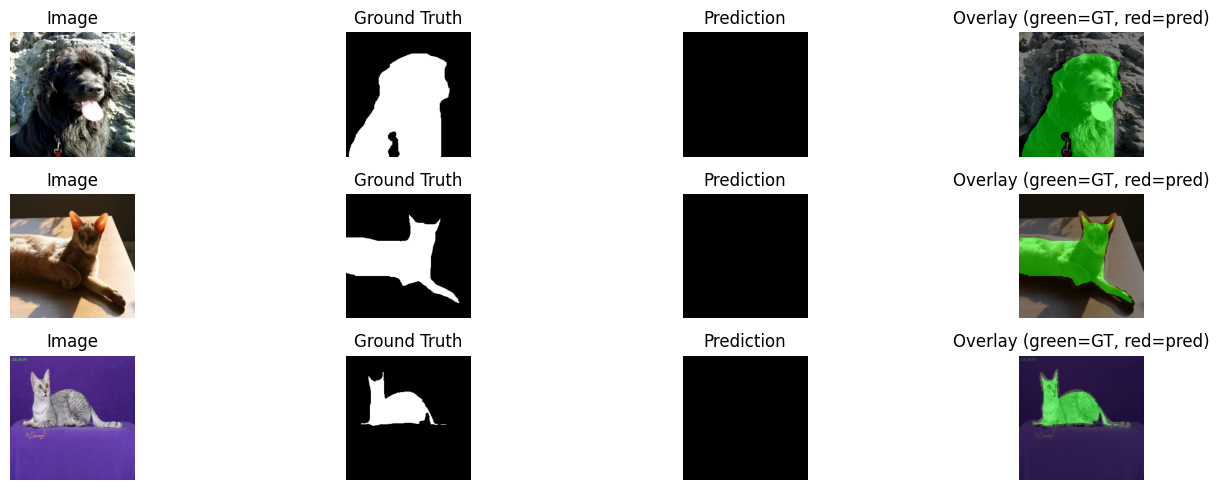

In [50]:
def visualize_segmentation(model, loader, threshold, idx=0, postprocess=None):
    model.eval()
    images, masks = next(iter(loader))
    images = images.to(DEVICE)
    masks = masks.to(DEVICE)
    with torch.no_grad():
        output = model(images)['out']
        probs = torch.softmax(output, dim=1)
        pred = (probs[:, 1, :, :] > threshold).long()
        if postprocess:
            pred = postprocess(pred)
    plt.figure(figsize=(15, 5))
    for i in range(3):  # показать 3 примера
        img = denorm_image(images[i])
        true_mask = masks[i].cpu().numpy()
        pred_mask = pred[i].cpu().numpy()
        plt.subplot(3, 4, i*4+1)
        plt.imshow(img)
        plt.title('Image')
        plt.axis('off')
        plt.subplot(3, 4, i*4+2)
        plt.imshow(true_mask, cmap='gray')
        plt.title('Ground Truth')
        plt.axis('off')
        plt.subplot(3, 4, i*4+3)
        plt.imshow(pred_mask, cmap='gray')
        plt.title('Prediction')
        plt.axis('off')
        plt.subplot(3, 4, i*4+4)
        # наложение
        overlay = np.zeros_like(img)
        overlay[true_mask>0] = [0, 1, 0]  # green ground truth
        overlay[pred_mask>0] = [1, 0, 0]  # red prediction
        plt.imshow(img)
        plt.imshow(overlay, alpha=0.5)
        plt.title('Overlay (green=GT, red=pred)')
        plt.axis('off')
    plt.tight_layout()
    plt.savefig('artifacts/figures/segmentation_examples.png')
    plt.show()

visualize_segmentation(model_seg, val_loader_pet, threshold=0.3, postprocess=None)
visualize_segmentation(model_seg, val_loader_pet, threshold=0.7, postprocess=postprocess_min_size)

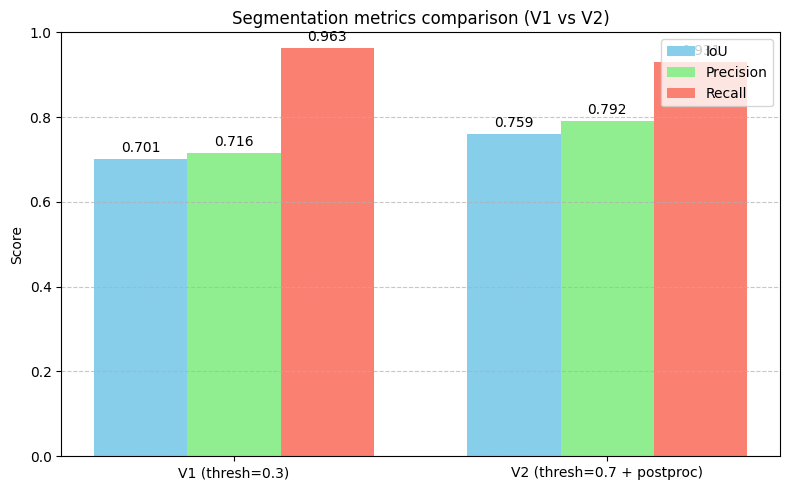

In [52]:
metrics_data = {
    'V1': {'IoU': metrics_v1[0], 'Precision': metrics_v1[1], 'Recall': metrics_v1[2]},
    'V2': {'IoU': metrics_v2[0], 'Precision': metrics_v2[1], 'Recall': metrics_v2[2]}
}

x = np.arange(2)  # два режима
width = 0.25
multiplier = 0

fig, ax = plt.subplots(figsize=(8,5))
for attribute, color in zip(['IoU', 'Precision', 'Recall'], ['skyblue', 'lightgreen', 'salmon']):
    offset = width * multiplier
    values = [metrics_data[mode][attribute] for mode in ['V1', 'V2']]
    rects = ax.bar(x + offset, values, width, label=attribute, color=color)
    ax.bar_label(rects, fmt='%.3f', padding=3)
    multiplier += 1

ax.set_ylabel('Score')
ax.set_title('Segmentation metrics comparison (V1 vs V2)')
ax.set_xticks(x + width, ['V1 (thresh=0.3)', 'V2 (thresh=0.7 + postproc)'])
ax.legend(loc='upper right')
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('artifacts/figures/segmentation_metrics.png')
plt.show()

In [53]:
# Добавляем строки для сегментации
results.extend([
    {
        'experiment_id': 'V1',
        'task': 'segmentation',
        'dataset': 'OxfordIIITPet',
        'seed': 42,
        'model_summary': 'DeepLabV3_ResNet50',
        'optimizer': '-',
        'lr': '-',
        'epochs_trained': 0,
        'best_val_accuracy': None,
        'test_accuracy': None,
        'precision': metrics_v1[1],
        'recall': metrics_v1[2],
        'mean_iou': metrics_v1[0],
        'notes': 'threshold=0.3'
    },
    {
        'experiment_id': 'V2',
        'task': 'segmentation',
        'dataset': 'OxfordIIITPet',
        'seed': 42,
        'model_summary': 'DeepLabV3_ResNet50',
        'optimizer': '-',
        'lr': '-',
        'epochs_trained': 0,
        'best_val_accuracy': None,
        'test_accuracy': None,
        'precision': metrics_v2[1],
        'recall': metrics_v2[2],
        'mean_iou': metrics_v2[0],
        'notes': 'threshold=0.7, postprocess=remove_small_components'
    }
])

df = pd.DataFrame(results)
df.to_csv('artifacts/runs.csv', index=False)
print("Результаты сохранены в artifacts/runs.csv")

Результаты сохранены в artifacts/runs.csv
